# SmartPDS — Demand Forecasting Module

Predicts village-level ration demand one month ahead using real Tamil Nadu PDS operational data. Four datasets are integrated: village demographics, FPS profiles, household ration cards, and 12-month transaction records. An XGBoost and Random Forest ensemble is trained on the resulting feature set and explained via SHAP.

**Pipeline:** Village Data + FPS Data + Ration Cards + Transactions -> Feature Engineering -> Train/Test Split -> XGBoost -> Random Forest -> Ensemble -> SHAP -> Forecast Export

**Data files required in same directory:**
- `villages.csv`
- `fps_data.csv`
- `ration_cards.csv`
- `transactions.csv`

## 0. Dependencies

In [1]:
!pip install xgboost scikit-learn shap pandas numpy matplotlib seaborn -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f5f5f5',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. Load Datasets

All four source files are loaded and basic validation checks are printed.

In [3]:
villages  = pd.read_csv('villages.csv')
fps       = pd.read_csv('fps_data.csv')
cards     = pd.read_csv('ration_cards.csv')
txn       = pd.read_csv('transactions.csv')

print(f'Villages    : {len(villages):>5} rows  | Columns: {list(villages.columns)}')
print(f'FPS         : {len(fps):>5} rows  | Columns: {list(fps.columns)}')
print(f'Ration Cards: {len(cards):>5} rows  | Columns: {list(cards.columns)}')
print(f'Transactions: {len(txn):>5} rows  | Columns: {list(txn.columns)}')
print()
print('Transaction months :', sorted(txn["mth_number"].unique()))
print('Commodities        :', txn["commodity"].unique().tolist())
print('Auth modes         :', txn["auth_mode"].unique().tolist())


Villages    :    50 rows  | Columns: ['village_id', 'village_name', 'district', 'block', 'block_panchayat', 'longitude', 'latitude', 'total_hh', 'avg_hh_size', 'perc_rural', 'ratio_female', 'nearest_town_km', 'has_fps', 'has_bus_service', 'has_road_connectivity']
FPS         :    50 rows  | Columns: ['fps_id', 'village_id', 'fps_name', 'district', 'block', 'owner_type', 'avg_mthly_transactions', 'devices', 'has_eRation', 'has_intra_state_portability']
Ration Cards:   502 rows  | Columns: ['card_id', 'village_id', 'district', 'block', 'card_type', 'bpl_status', 'household_size', 'gender_head', 'age_head', 'monthly_income_band', 'fps_id', 'registered_online', 'has_aadhaar']
Transactions: 14249 rows  | Columns: ['txn_id', 'card_id', 'fps_id', 'village_id', 'district', 'block', 'month', 'commodity', 'unit_price', 'quantity', 'amount', 'mth_number', 'year', 'auth_mode', 'offline_flag', 'delivery_delay_days']

Transaction months : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64

## 2. Exploratory Data Analysis

Commodity distribution, monthly demand trend, village-level collection rates, and delivery delay distribution.

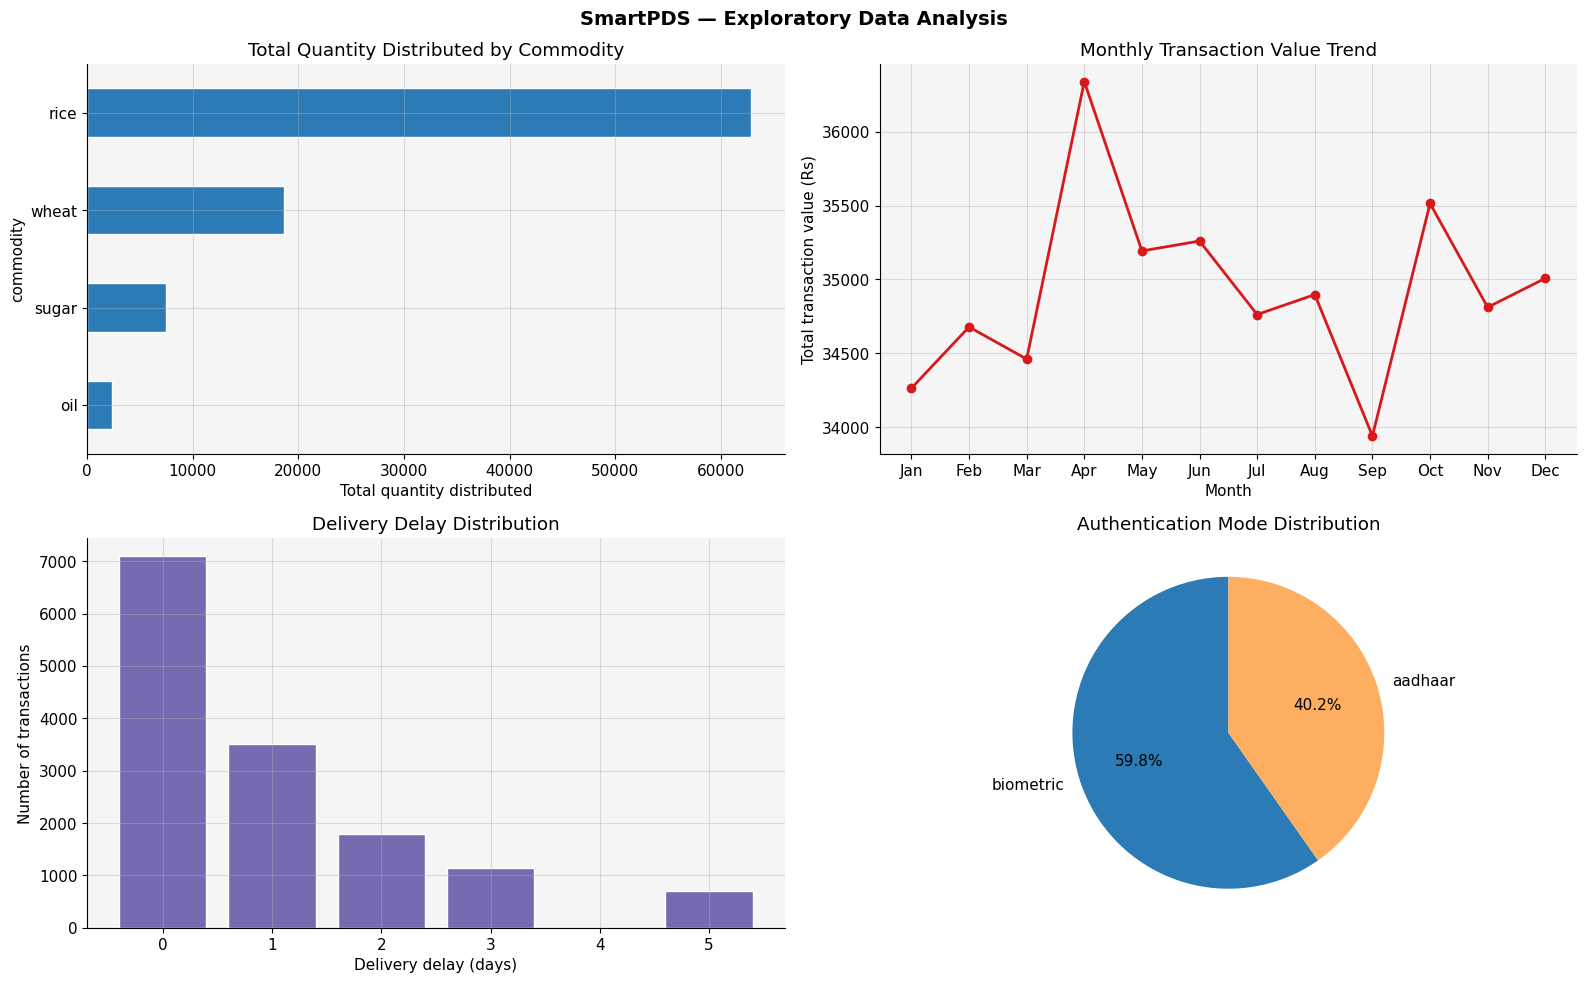

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('SmartPDS — Exploratory Data Analysis', fontsize=14, fontweight='bold')

comm_qty = txn.groupby('commodity')['quantity'].sum().sort_values(ascending=True)
comm_qty.plot(kind='barh', ax=axes[0,0], color='#2c7bb6', edgecolor='white')
axes[0,0].set_xlabel('Total quantity distributed')
axes[0,0].set_title('Total Quantity Distributed by Commodity')

monthly = txn.groupby('mth_number')['amount'].sum()
axes[0,1].plot(monthly.index, monthly.values, 'o-', color='#d7191c', lw=2)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total transaction value (Rs)')
axes[0,1].set_title('Monthly Transaction Value Trend')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

delay_dist = txn['delivery_delay_days'].value_counts().sort_index()
axes[1,0].bar(delay_dist.index, delay_dist.values, color='#756bb1', edgecolor='white')
axes[1,0].set_xlabel('Delivery delay (days)')
axes[1,0].set_ylabel('Number of transactions')
axes[1,0].set_title('Delivery Delay Distribution')

auth_dist = txn['auth_mode'].value_counts()
axes[1,1].pie(auth_dist.values, labels=auth_dist.index, autopct='%1.1f%%',
              colors=['#2c7bb6','#fdae61'], startangle=90)
axes[1,1].set_title('Authentication Mode Distribution')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Feature Engineering — Village-Month Panel

Transaction data is aggregated to a village-month panel. Village demographics (household count, FPS devices, connectivity) and card-level statistics (PHH/AAY mix, household size) are joined. Seasonal flags, lag features, and rolling statistics are then computed.

In [5]:
# Village-month demand aggregation
rice_txn = txn[txn['commodity'] == 'rice'].copy()
panel = (
    rice_txn.groupby(['village_id', 'mth_number'])
    .agg(
        demand_kg        =('quantity', 'sum'),
        txn_count        =('txn_id', 'count'),
        avg_delay        =('delivery_delay_days', 'mean'),
        offline_pct      =('offline_flag', 'mean'),
        aadhaar_pct      =('auth_mode', lambda x: (x == 'aadhaar').mean()),
    ).reset_index()
)

# Card-level aggregates per village
card_agg = (
    cards.groupby('village_id')
    .agg(
        total_cards      =('card_id', 'count'),
        phh_count        =('card_type', lambda x: (x == 'PHH').sum()),
        aay_count        =('card_type', lambda x: (x == 'AAY').sum()),
        avg_hh_size_card =('household_size', 'mean'),
        bpl_count        =('bpl_status', 'sum'),
        aadhaar_coverage =('has_aadhaar', 'mean'),
    ).reset_index()
)
card_agg['phh_ratio'] = card_agg['phh_count'] / card_agg['total_cards']

# Village demographics
vil_feats = villages[['village_id','total_hh','avg_hh_size','perc_rural',
                       'ratio_female','nearest_town_km']].copy()

# FPS features
fps_feats = fps[['village_id','avg_mthly_transactions','devices',
                 'has_eRation','has_intra_state_portability']].copy()

# Join all
df = panel.copy()
df = df.merge(card_agg,  on='village_id', how='left')
df = df.merge(vil_feats, on='village_id', how='left')
df = df.merge(fps_feats, on='village_id', how='left')

print(f'Panel shape after join: {df.shape}')
df.head()


Panel shape after join: (600, 23)


,village_id,mth_number,demand_kg,txn_count,avg_delay,offline_pct,aadhaar_pct,total_cards,phh_count,aay_count,...,phh_ratio,total_hh,avg_hh_size,perc_rural,ratio_female,nearest_town_km,avg_mthly_transactions,devices,has_eRation,has_intra_state_portability
0,1,1,79,7,1.142857,0.142857,0.285714,8,6,2,...,0.75,1250,4.8,0.95,0.49,12,1800,2,1,1
1,1,2,93,8,0.500000,0.125000,0.375000,8,6,2,...,0.75,1250,4.8,0.95,0.49,12,1800,2,1,1
2,1,3,69,6,1.333333,0.000000,0.500000,8,6,2,...,0.75,1250,4.8,0.95,0.49,12,1800,2,1,1
3,1,4,96,8,1.000000,0.000000,0.375000,8,6,2,...,0.75,1250,4.8,0.95,0.49,12,1800,2,1,1
4,1,5,82,7,1.428571,0.000000,0.142857,8,6,2,...,0.75,1250,4.8,0.95,0.49,12,1800,2,1,1


In [6]:
# Seasonal flags
FESTIVAL_MONTHS = [1, 4, 10, 11]
DROUGHT_MONTHS  = [4, 5, 6]
HARVEST_MONTHS  = [11, 12]

df['festival_flag'] = df['mth_number'].isin(FESTIVAL_MONTHS).astype(int)
df['drought_flag']  = df['mth_number'].isin(DROUGHT_MONTHS).astype(int)
df['harvest_flag']  = df['mth_number'].isin(HARVEST_MONTHS).astype(int)
df['month_sin']     = np.sin(2 * np.pi * df['mth_number'] / 12)
df['month_cos']     = np.cos(2 * np.pi * df['mth_number'] / 12)

# Lag and rolling features per village
df = df.sort_values(['village_id','mth_number']).reset_index(drop=True)

for lag in [1, 2, 3]:
    df[f'demand_lag_{lag}'] = df.groupby('village_id')['demand_kg'].shift(lag)

df['demand_roll_mean_3'] = (
    df.groupby('village_id')['demand_kg']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
df['demand_roll_std_3'] = (
    df.groupby('village_id')['demand_kg']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std().fillna(0))
)
df['demand_roll_max_3'] = (
    df.groupby('village_id')['demand_kg']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).max())
)

df.dropna(subset=['demand_lag_1','demand_lag_2','demand_lag_3'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Records after lag drop : {len(df):,}')
print(f'Null check             : {df.isnull().sum().sum()} nulls')


Records after lag drop : 450
Null check             : 0 nulls


## 4. Feature Set Definition

Final feature list spanning transaction behaviour, card demographics, village infrastructure, and temporal signals.

In [7]:
FEATURES = [
    # Transaction behaviour
    'txn_count', 'avg_delay', 'offline_pct', 'aadhaar_pct',
    # Card demographics
    'total_cards', 'bpl_count', 'phh_ratio', 'avg_hh_size_card', 'aadhaar_coverage',
    # Village infrastructure
    'total_hh', 'avg_hh_size', 'perc_rural', 'ratio_female', 'nearest_town_km',
    # FPS profile
    'avg_mthly_transactions', 'devices', 'has_eRation', 'has_intra_state_portability',
    # Lag and rolling
    'demand_lag_1', 'demand_lag_2', 'demand_lag_3',
    'demand_roll_mean_3', 'demand_roll_std_3', 'demand_roll_max_3',
    # Seasonal
    'festival_flag', 'drought_flag', 'harvest_flag',
    'month_sin', 'month_cos',
]
TARGET = 'demand_kg'

print(f'Total features : {len(FEATURES)}')
print(f'Target         : {TARGET}')
print()
print(df[FEATURES + [TARGET]].describe().round(2))


Total features : 29
Target         : demand_kg

       txn_count  avg_delay  offline_pct  aadhaar_pct  total_cards  bpl_count  \
count     450.00     450.00       450.00       450.00       450.00     450.00   
mean        8.79       0.98         0.05         0.40        10.04       5.68   
std         1.73       0.44         0.08         0.16         1.52       1.67   
min         4.00       0.00         0.00         0.00         8.00       3.00   
25%         8.00       0.67         0.00         0.29         9.00       4.00   
50%         9.00       0.92         0.00         0.40        10.00       6.00   
75%        10.00       1.25         0.10         0.50        11.00       7.00   
max        12.00       3.00         0.40         1.00        12.00       9.00   

       phh_ratio  avg_hh_size_card  aadhaar_coverage  total_hh  ...  \
count     450.00            450.00             450.0    450.00  ...   
mean        0.56              5.09               1.0   1176.00  ...   
std      

## 5. Train/Test Split

Time-based split: months 1-9 used for training, months 10-12 held out for testing. No random shuffling is applied to prevent data leakage.

In [8]:
TRAIN_CUTOFF = 10

train_df = df[df['mth_number'] < TRAIN_CUTOFF]
test_df  = df[df['mth_number'] >= TRAIN_CUTOFF]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

assert train_df['mth_number'].max() < test_df['mth_number'].min(), \
    'Data leakage: train and test months overlap.'

print(f'Training records : {len(X_train):>5}  (months 4 to {TRAIN_CUTOFF - 1})')
print(f'Test records     : {len(X_test):>5}  (months {TRAIN_CUTOFF} to 12)')
print(f'Train/Test split : {len(X_train)/len(df)*100:.1f}% / {len(X_test)/len(df)*100:.1f}%')


Training records :   300  (months 4 to 9)
Test records     :   150  (months 10 to 12)
Train/Test split : 66.7% / 33.3%


## 6. Model Training

XGBoost and Random Forest regressors are trained independently on the same feature set. A 60/40 weighted ensemble is formed for final predictions.

In [9]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
print('XGBoost training complete.')


XGBoost training complete.


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
print('Random Forest training complete.')


Random Forest training complete.


In [11]:
XGB_WEIGHT = 0.60
RF_WEIGHT  = 0.40

xgb_preds      = xgb_model.predict(X_test)
rf_preds       = rf_model.predict(X_test)
ensemble_preds = XGB_WEIGHT * xgb_preds + RF_WEIGHT * rf_preds

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'{name:<22} R2={r2:.4f}   RMSE={rmse:7.2f} kg   MAE={mae:7.2f} kg')
    return r2, rmse, mae

print(f'{"Model":<22} {"R2":<13} {"RMSE":<21} {"MAE"}')
print('-' * 65)
evaluate('XGBoost',       y_test, xgb_preds)
evaluate('Random Forest', y_test, rf_preds)
ens_r2, ens_rmse, ens_mae = evaluate('Ensemble (60/40)', y_test, ensemble_preds)


Model                  R2            RMSE                  MAE
-----------------------------------------------------------------
XGBoost                R2=0.8522   RMSE=   8.46 kg   MAE=   6.51 kg
Random Forest          R2=0.7877   RMSE=  10.14 kg   MAE=   7.73 kg
Ensemble (60/40)       R2=0.8468   RMSE=   8.61 kg   MAE=   6.68 kg


## 7. Evaluation Plots

Actual vs predicted scatter, residuals distribution, sample village time-series, and XGBoost feature importance.

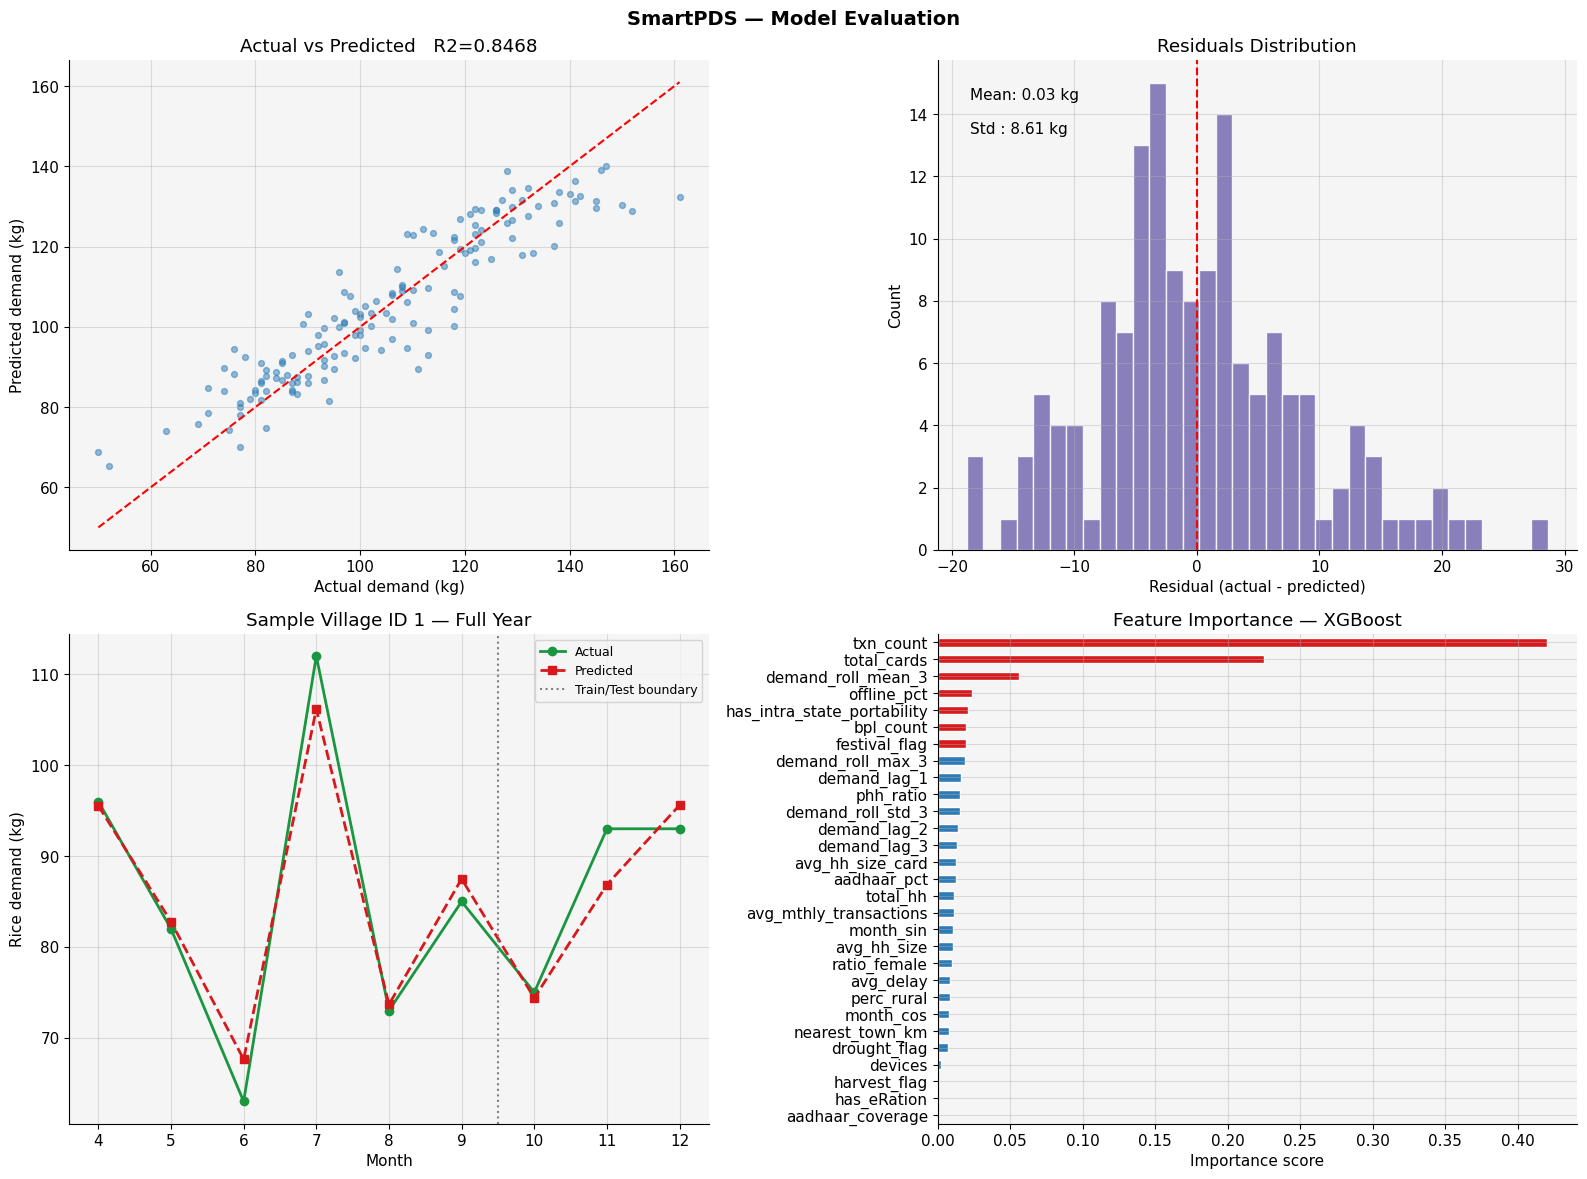

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SmartPDS — Model Evaluation', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.scatter(y_test, ensemble_preds, alpha=0.5, s=18, color='#2c7bb6')
lims = [min(y_test.min(), ensemble_preds.min()),
        max(y_test.max(), ensemble_preds.max())]
ax.plot(lims, lims, 'r--', lw=1.5)
ax.set_xlabel('Actual demand (kg)')
ax.set_ylabel('Predicted demand (kg)')
ax.set_title(f'Actual vs Predicted   R2={ens_r2:.4f}')

ax = axes[0, 1]
residuals = y_test.values - ensemble_preds
ax.hist(residuals, bins=35, color='#756bb1', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title('Residuals Distribution')
ax.text(0.05, 0.92, f'Mean: {residuals.mean():.2f} kg', transform=ax.transAxes)
ax.text(0.05, 0.85, f'Std : {residuals.std():.2f} kg',  transform=ax.transAxes)

ax = axes[1, 0]
sv_id    = test_df['village_id'].unique()[0]
sv       = df[df['village_id'] == sv_id].copy()
sv_preds = (XGB_WEIGHT * xgb_model.predict(sv[FEATURES]) +
            RF_WEIGHT  * rf_model.predict(sv[FEATURES]))
ax.plot(sv['mth_number'].values, sv['demand_kg'].values,
        'o-', lw=2, label='Actual', color='#1a9641')
ax.plot(sv['mth_number'].values, sv_preds,
        's--', lw=2, label='Predicted', color='#d7191c')
ax.axvline(TRAIN_CUTOFF - 0.5, color='gray', linestyle=':', lw=1.5, label='Train/Test boundary')
ax.set_xlabel('Month')
ax.set_ylabel('Rice demand (kg)')
ax.set_title(f'Sample Village ID {sv_id} — Full Year')
ax.legend(fontsize=9)

ax = axes[1, 1]
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
bar_cols    = ['#d7191c' if v > importances.quantile(0.75) else '#2c7bb6'
               for v in importances]
importances.plot(kind='barh', ax=ax, color=bar_cols, edgecolor='white')
ax.set_title('Feature Importance — XGBoost')
ax.set_xlabel('Importance score')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. FPS Performance Analysis

Village-level collection rates, average delivery delays, and offline transaction proportions — derived from the transaction dataset.

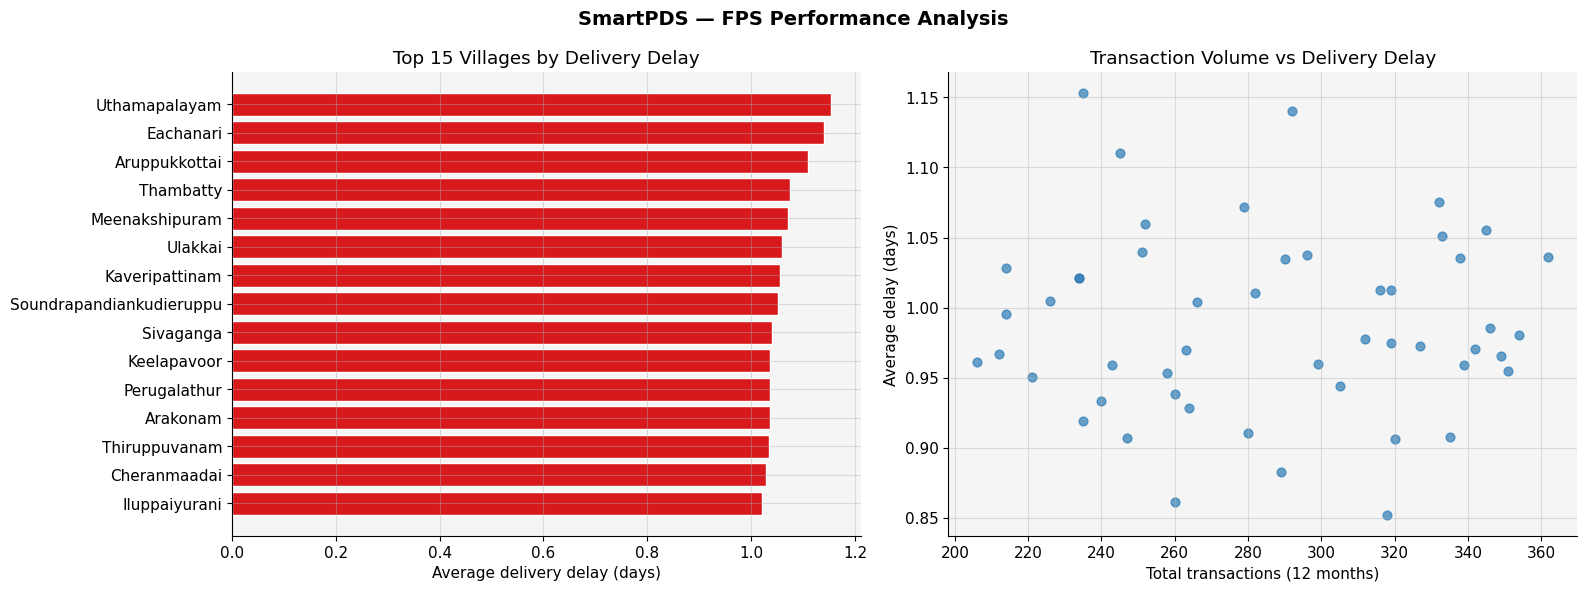

            village_name      district  total_txns  avg_delay  offline_pct  total_value
           Uthamapalayam         Theni         235   1.153191     0.012766         6854
               Eachanari    Coimbatore         292   1.140411     0.041096         8522
           Aruppukkottai  Virudhunagar         245   1.110204     0.024490         6979
               Thambatty      Nilgiris         332   1.075301     0.033133         9746
          Meenakshipuram   Tirunelveli         279   1.071685     0.057348         8387
                 Ulakkai Kanniyakumari         252   1.059524     0.067460         7154
          Kaveripattinam Kanniyakumari         345   1.055072     0.040580         9980
Soundrapandiankudieruppu   Tirunelveli         333   1.051051     0.030030         9705
               Sivaganga    Sivagangai         251   1.039841     0.055777         7651
             Keelapavoor       Tenkasi         296   1.037162     0.094595         8624


In [13]:
fps_perf = (
    txn.groupby('village_id')
    .agg(
        total_txns    =('txn_id', 'count'),
        avg_delay     =('delivery_delay_days', 'mean'),
        offline_pct   =('offline_flag', 'mean'),
        total_value   =('amount', 'sum'),
        total_rice_kg =('quantity', lambda x: x[txn.loc[x.index, 'commodity'] == 'rice'].sum()),
    ).reset_index()
)
fps_perf = fps_perf.merge(villages[['village_id','village_name','district']], on='village_id')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SmartPDS — FPS Performance Analysis', fontsize=14, fontweight='bold')

top_delay = fps_perf.nlargest(15, 'avg_delay')
axes[0].barh(top_delay['village_name'], top_delay['avg_delay'],
             color='#d7191c', edgecolor='white')
axes[0].set_xlabel('Average delivery delay (days)')
axes[0].set_title('Top 15 Villages by Delivery Delay')
axes[0].invert_yaxis()

axes[1].scatter(fps_perf['total_txns'], fps_perf['avg_delay'],
                alpha=0.7, s=40, color='#2c7bb6')
axes[1].set_xlabel('Total transactions (12 months)')
axes[1].set_ylabel('Average delay (days)')
axes[1].set_title('Transaction Volume vs Delivery Delay')

plt.tight_layout()
plt.savefig('fps_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(fps_perf[['village_name','district','total_txns','avg_delay',
                'offline_pct','total_value']].sort_values('avg_delay', ascending=False)
      .head(10).to_string(index=False))


## 9. SHAP Explainability

SHAP values quantify each feature's contribution to individual predictions, providing transparency required for AI governance in government deployments.

Computing SHAP values...


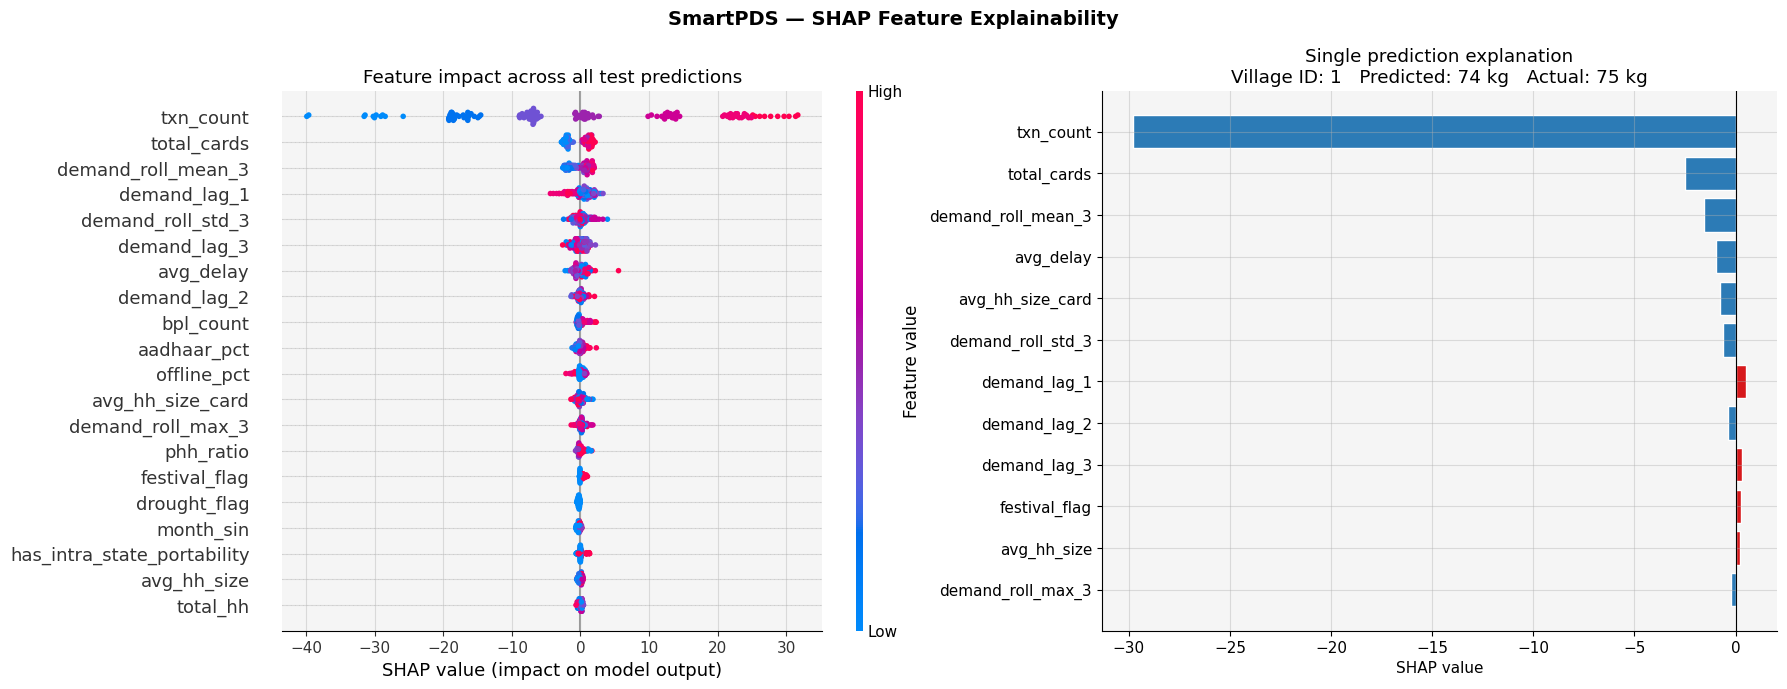

In [14]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SmartPDS — SHAP Feature Explainability', fontsize=14, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False, plot_size=None)
axes[0].set_title('Feature impact across all test predictions')

plt.sca(axes[1])
shap_single = shap_values[0]
sorted_idx  = np.argsort(np.abs(shap_single))[-12:]
feat_names  = [FEATURES[i] for i in sorted_idx]
feat_shap   = shap_single[sorted_idx]
bar_colors  = ['#d7191c' if v > 0 else '#2c7bb6' for v in feat_shap]
axes[1].barh(feat_names, feat_shap, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('SHAP value')
axes[1].set_title(
    f'Single prediction explanation\n'
    f'Village ID: {test_df["village_id"].iloc[0]}   '
    f'Predicted: {ensemble_preds[0]:.0f} kg   '
    f'Actual: {y_test.iloc[0]:.0f} kg'
)

plt.tight_layout()
plt.savefig('shap.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. One-Month Ahead Forecast

In [15]:
latest = df.loc[df.groupby('village_id')['mth_number'].idxmax()].copy()

ens_forecast = (
    XGB_WEIGHT * xgb_model.predict(latest[FEATURES]) +
    RF_WEIGHT  * rf_model.predict(latest[FEATURES])
)

forecast_df = pd.DataFrame({
    'village_id':           latest['village_id'].values,
    'bpl_count':            latest['bpl_count'].values,
    'last_actual_kg':       latest['demand_kg'].values,
    'forecasted_demand_kg': np.round(ens_forecast, 1),
}).sort_values('forecasted_demand_kg', ascending=False).reset_index(drop=True)

forecast_df = forecast_df.merge(
    villages[['village_id','village_name','district']], on='village_id'
)

forecast_df['shortage_risk'] = pd.cut(
    forecast_df['forecasted_demand_kg'],
    bins=[0, 50, 120, np.inf],
    labels=['Low', 'Medium', 'High']
)

print(f'Villages forecasted  : {len(forecast_df)}')
print(f'High shortage risk   : {(forecast_df["shortage_risk"] == "High").sum()}')
print(f'Medium shortage risk : {(forecast_df["shortage_risk"] == "Medium").sum()}')
print()
print(forecast_df[['village_id','village_name','district',
                    'bpl_count','last_actual_kg','forecasted_demand_kg',
                    'shortage_risk']].head(15).to_string(index=False))


Villages forecasted  : 50
High shortage risk   : 14
Medium shortage risk : 36

 village_id             village_name      district  bpl_count  last_actual_kg  forecasted_demand_kg shortage_risk
          2                Seruvayur     Tuticorin          9             147                 140.0          High
         15             Perugalathur  Chengalpattu          6             141                 136.5          High
         47                 Arakonam       Vellore          7             140                 133.0          High
         36                 Kallanai     Thanjavur          7             131                 131.7          High
         11            Vandithavalam       Tenkasi          5             127                 131.6          High
         34            Kunnumbikulam     Thanjavur          6             141                 131.3          High
         43                    Avadi       Chennai          8             137                 130.9          High
         

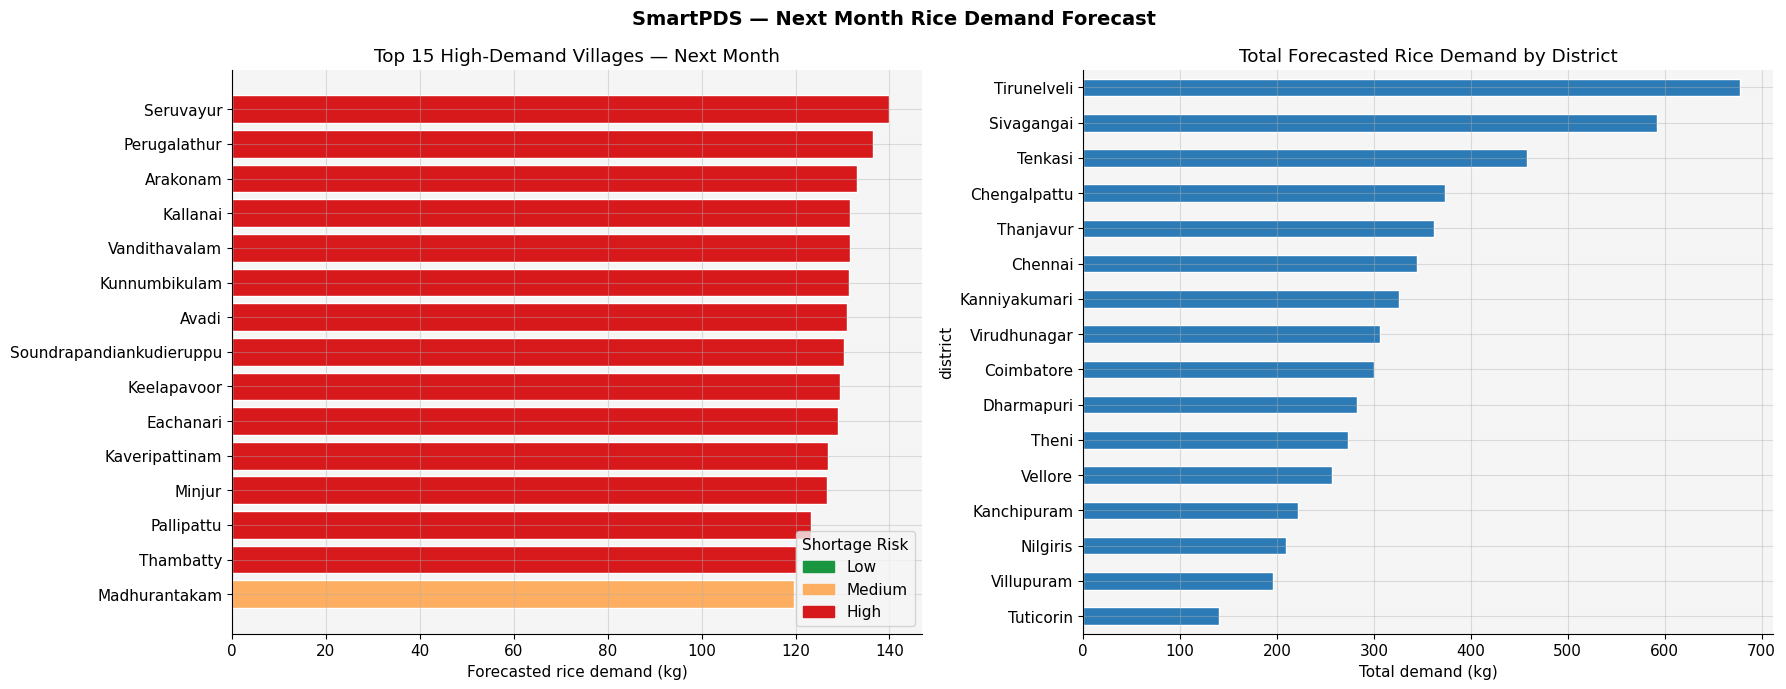

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SmartPDS — Next Month Rice Demand Forecast', fontsize=14, fontweight='bold')

risk_colors = {'Low': '#1a9641', 'Medium': '#fdae61', 'High': '#d7191c'}
top15       = forecast_df.head(15)
bar_colors  = [risk_colors[str(r)] for r in top15['shortage_risk']]

axes[0].barh(top15['village_name'], top15['forecasted_demand_kg'],
             color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Forecasted rice demand (kg)')
axes[0].set_title('Top 15 High-Demand Villages — Next Month')
axes[0].invert_yaxis()

from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color=c, label=l) for l, c in risk_colors.items()],
    title='Shortage Risk'
)

dist_forecast = (
    forecast_df.merge(villages[['village_id','district']], on='village_id', suffixes=('','_v'))
    .groupby('district')['forecasted_demand_kg'].sum().sort_values(ascending=True)
)
dist_forecast.plot(kind='barh', ax=axes[1], color='#2c7bb6', edgecolor='white')
axes[1].set_title('Total Forecasted Rice Demand by District')
axes[1].set_xlabel('Total demand (kg)')

plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Export Outputs

The forecast CSV is the direct input to Module 2 — the OR-Tools LP Allocation Optimizer. Both model binaries are saved for reuse in the inference pipeline.

In [17]:
forecast_df[['village_id','village_name','district','bpl_count',
             'forecasted_demand_kg','shortage_risk']]\
    .to_csv('village_demand_forecast.csv', index=False)

with open('xgb_model.pkl', 'wb') as f: pickle.dump(xgb_model, f)
with open('rf_model.pkl',  'wb') as f: pickle.dump(rf_model,  f)

print('Outputs written:')
print('  village_demand_forecast.csv  — input for LP Allocation Optimizer')
print('  xgb_model.pkl               — trained XGBoost model')
print('  rf_model.pkl                — trained Random Forest model')
print()
print('Final Model Performance')
print('-' * 45)
print(f'  Ensemble R2   : {ens_r2:.4f}')
print(f'  Ensemble RMSE : {ens_rmse:.2f} kg')
print(f'  Ensemble MAE  : {ens_mae:.2f} kg')
print(f'  Villages      : {len(forecast_df)}')
print(f'  Features      : {len(FEATURES)}')
print(f'  Transactions  : {len(txn):,}')
print(f'  Ration cards  : {len(cards):,}')
print('-' * 45)
print()
print('Data sources')
print('  villages.csv       — 50 Tamil Nadu villages')
print('  fps_data.csv       — FPS profiles for all villages')
print('  ration_cards.csv   — household-level NFSA card register')
print('  transactions.csv   — 12-month PDS transaction records')


Outputs written:
  village_demand_forecast.csv  — input for LP Allocation Optimizer
  xgb_model.pkl               — trained XGBoost model
  rf_model.pkl                — trained Random Forest model

Final Model Performance
---------------------------------------------
  Ensemble R2   : 0.8468
  Ensemble RMSE : 8.61 kg
  Ensemble MAE  : 6.68 kg
  Villages      : 50
  Features      : 29
  Transactions  : 14,249
  Ration cards  : 502
---------------------------------------------

Data sources
  villages.csv       — 50 Tamil Nadu villages
  fps_data.csv       — FPS profiles for all villages
  ration_cards.csv   — household-level NFSA card register
  transactions.csv   — 12-month PDS transaction records
